# Average price of restaurants in Lausanne based on Location 
### This will be a bar graph

In [86]:
### Libraries:
import pandas 
import numpy
import matplotlib
import matplotlib.pyplot as plt

### Choose a graphical output style:

# Static (most reliable)
%matplotlib inline 


In [87]:
#Read data and display
data = pandas.read_csv(r"C:\School\Data Vis\mini_proj\data-viz-mini-proj-2\Data\combined_group_data_price_range_cleaned.csv")
data.tail()

,Observation ID,Name,Data Type,Latitude,Longitude,Color,Material,Town,Link to Picture,Open/Closed,Number of People,Price Range (CHF)
311,G3_L62,Globus,Retail & Clothing,46.521730,6.634001,NaN,NaN,Lausanne,https://drive.google.com/file/d/1olTiIXa5oULOU...,NaN,NaN,10-200
312,G3_L63,Walpurgis,Retail & Clothing,46.521862,6.633977,NaN,NaN,Lausanne,https://drive.google.com/file/d/1olTiIXa5oULOU...,NaN,NaN,20-200
313,G3_L64,Collection 66,Retail & Clothing,46.521909,6.633959,NaN,NaN,Lausanne,https://drive.google.com/file/d/14qHoia3XI-oar...,NaN,NaN,20-200
314,G3_L65,D’Luxe,Retail & Clothing,46.521914,6.633951,NaN,NaN,Lausanne,https://docs.google.com/spreadsheets/d/1b9DfB8...,NaN,NaN,20-200
315,G3_L66,Jérôme Coiffure,Personal Care and Health,46.521915,6.633769,NaN,NaN,Lausanne,https://drive.google.com/file/d/1vGzNu6SyG0o1V...,NaN,NaN,10-100


In [88]:
# Average price of restaurants in lausanne based on location

# Two scatter plots with a color gradiant based on the low and high range
# color is the prices 
# X and Y is the longitude and latitude

#filter only for lausanne data from group 3
laus = data[data["Observation ID"].str.contains("G3_L", na=False)].copy() 
#laus.head()


#Separating data into the low prices and high prices
data_low = laus.copy()
data_high = laus.copy()
# data_low.dtypes


low = data_low["Price Range (CHF)"].map(
    lambda s: 0.0 if pandas.isna(s) or str(s) in ("N/A", "nan")
    else float(str(s).split('-')[0].strip())
)

data_low["Price Range (CHF)"] = low
data_low = data_low[data_low["Price Range (CHF)"] != 0.0]

#data_low.head(30)

high = data_high["Price Range (CHF)"].map(
    lambda s: 0.0 if pandas.isna(s) or str(s) in ("N/A", "nan")
    else float(str(s).split('-')[1].strip())
)

data_high["Price Range (CHF)"] = high
data_high = data_high[data_high["Price Range (CHF)"] != 0.0]


# data_high.head(30)








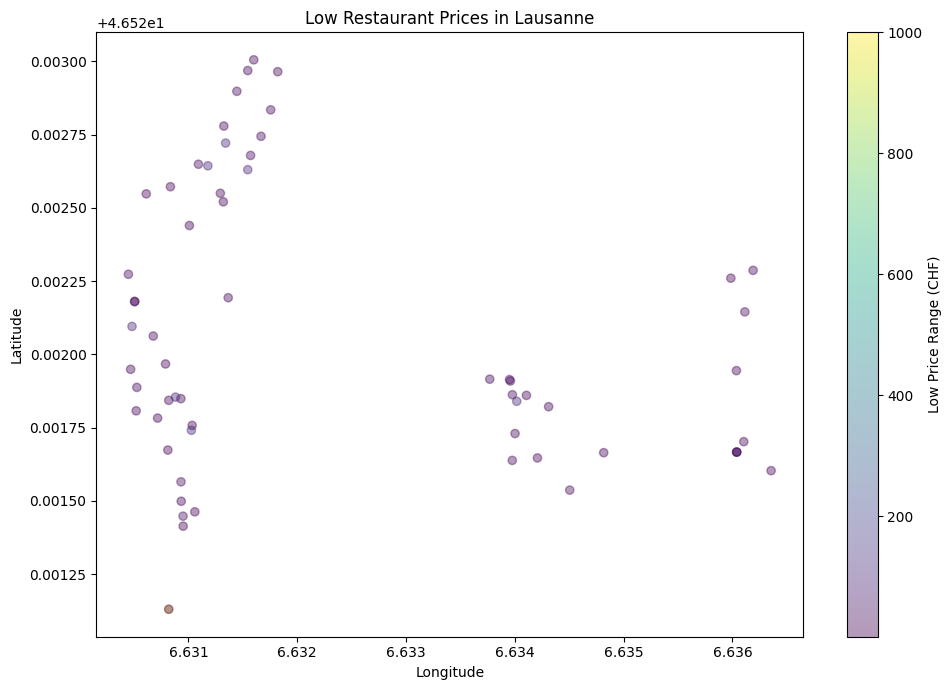

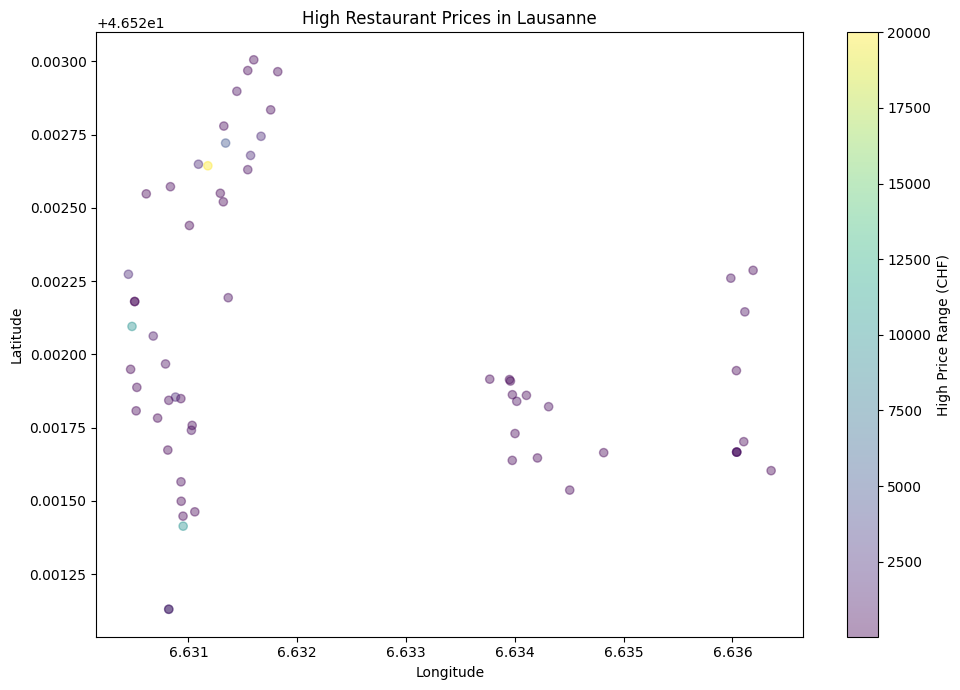

In [89]:
# Low price range scatter plot
fig, ax = plt.subplots(figsize=(10, 7))

scatter = ax.scatter(
    x=data_low['Longitude'],
    y=data_low['Latitude'],
    c=data_low['Price Range (CHF)'],
    cmap='viridis',
    alpha=0.4
)

plt.colorbar(scatter, ax=ax, label='Low Price Range (CHF)')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.set_title('Low Restaurant Prices in Lausanne')
plt.tight_layout()
plt.show()

# High price range scatter plot
fig, ax = plt.subplots(figsize=(10, 7))

scatter = ax.scatter(
    x=data_high['Longitude'],
    y=data_high['Latitude'],
    c=data_high['Price Range (CHF)'],
    cmap='viridis',
    alpha=0.4
)

plt.colorbar(scatter, ax=ax, label='High Price Range (CHF)')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.set_title('High Restaurant Prices in Lausanne')
plt.tight_layout()
plt.show()

